In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("restaurant_deliveries.csv")
df

,Order Date,Customer Location Latitude,Customer Location Longitude
0,2024-10-30,-64.422765,-104.314848
1,2024-11-06,38.715505,-93.664296
2,2024-03-28,-82.208504,-13.563827
3,2024-11-24,88.750964,44.094277
4,2024-10-11,53.461366,-56.535313
...,...,...,...
49995,2024-07-31,16.003230,-110.385825
49996,2024-08-23,-51.499978,60.187253
49997,2024-02-14,-56.227167,137.400090
49998,2024-04-28,70.467715,-20.828838


In [4]:
scaler = StandardScaler()
df[["Latitude_Scaled","Longitude_Scaled"]] = scaler.fit_transform(df[["Customer Location Latitude","Customer Location Longitude"]])
df

,Order Date,Customer Location Latitude,Customer Location Longitude,Latitude_Scaled,Longitude_Scaled
0,2024-10-30,-64.422765,-104.314848,-1.257365,-0.980006
1,2024-11-06,38.715505,-93.664296,0.712035,-0.877383
2,2024-03-28,-82.208504,-13.563827,-1.596979,-0.105578
3,2024-11-24,88.750964,44.094277,1.667450,0.449985
4,2024-10-11,53.461366,-56.535313,0.993603,-0.519628
...,...,...,...,...,...
49995,2024-07-31,16.003230,-110.385825,0.278350,-1.038502
49996,2024-08-23,-51.499978,60.187253,-1.010607,0.605048
49997,2024-02-14,-56.227167,137.400090,-1.100872,1.349029
49998,2024-04-28,70.467715,-20.828838,1.318336,-0.175579


In [6]:
def find_optmial_k(data, max_k):
    means = []
    inertias = []
    for i in range(1, max_k+1):
        kmeans_find = KMeans(n_clusters=i)
        kmeans_find.fit(data)
        means.append(i)
        inertias.append(kmeans_find.inertia_)

    plt.plot(means, inertias, 'o-')
    plt.plot(means, inertias, 'o-')
    plt.xlabel("Number of Clusters")
    plt.ylabel("Intertia")
    plt.grid(True)
    plt.show()

c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

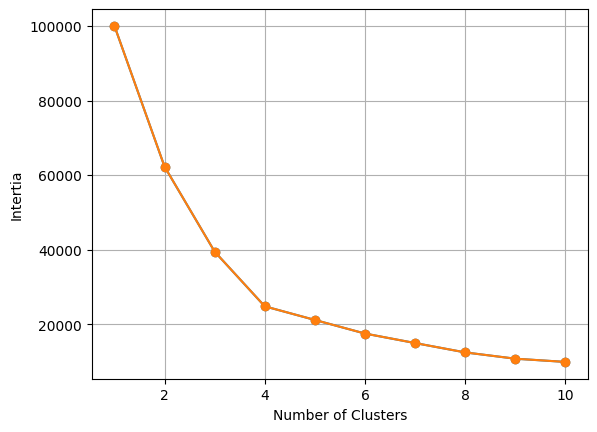

In [7]:
find_optmial_k(df[["Latitude_Scaled", "Longitude_Scaled"]], 10)

In [8]:
kmeans_optimal = KMeans(n_clusters=4)
kmeans_optimal.fit(df[["Latitude_Scaled", "Longitude_Scaled"]])

KMeans(n_clusters=4)

In [10]:
df["kmeans_3"] = kmeans_optimal.labels_

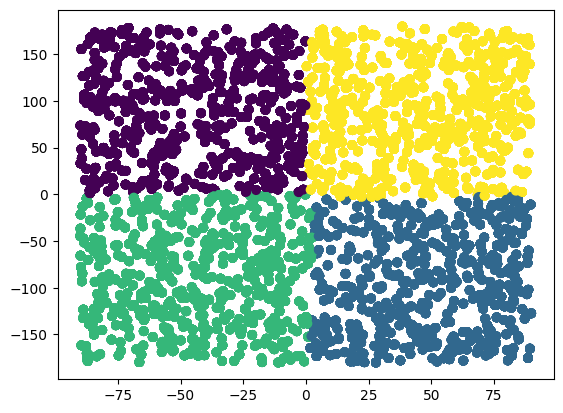

In [11]:
plt.scatter(
    x=df["Customer Location Latitude"],
    y=df["Customer Location Longitude"],
    c=df["kmeans_3"]
)
plt.show()

In [12]:
for k in range(3, 6+1):
    kmeans_multi = KMeans(n_clusters=k)
    kmeans_multi.fit(df[["Latitude_Scaled", "Longitude_Scaled"]])
    df[f"K-Means = {k}"] = kmeans_multi.labels_

In [13]:
df

,Order Date,Customer Location Latitude,Customer Location Longitude,Latitude_Scaled,Longitude_Scaled,kmeans_3,K-Means = 3,K-Means = 4,K-Means = 5,K-Means = 6
0,2024-10-30,-64.422765,-104.314848,-1.257365,-0.980006,2,1,2,4,1
1,2024-11-06,38.715505,-93.664296,0.712035,-0.877383,1,1,1,0,2
2,2024-03-28,-82.208504,-13.563827,-1.596979,-0.105578,2,2,2,4,1
3,2024-11-24,88.750964,44.094277,1.667450,0.449985,3,0,3,2,0
4,2024-10-11,53.461366,-56.535313,0.993603,-0.519628,1,0,1,0,2
...,...,...,...,...,...,...,...,...,...,...
49995,2024-07-31,16.003230,-110.385825,0.278350,-1.038502,1,1,1,0,4
49996,2024-08-23,-51.499978,60.187253,-1.010607,0.605048,0,2,0,3,5
49997,2024-02-14,-56.227167,137.400090,-1.100872,1.349029,0,2,0,3,5
49998,2024-04-28,70.467715,-20.828838,1.318336,-0.175579,1,0,1,0,2


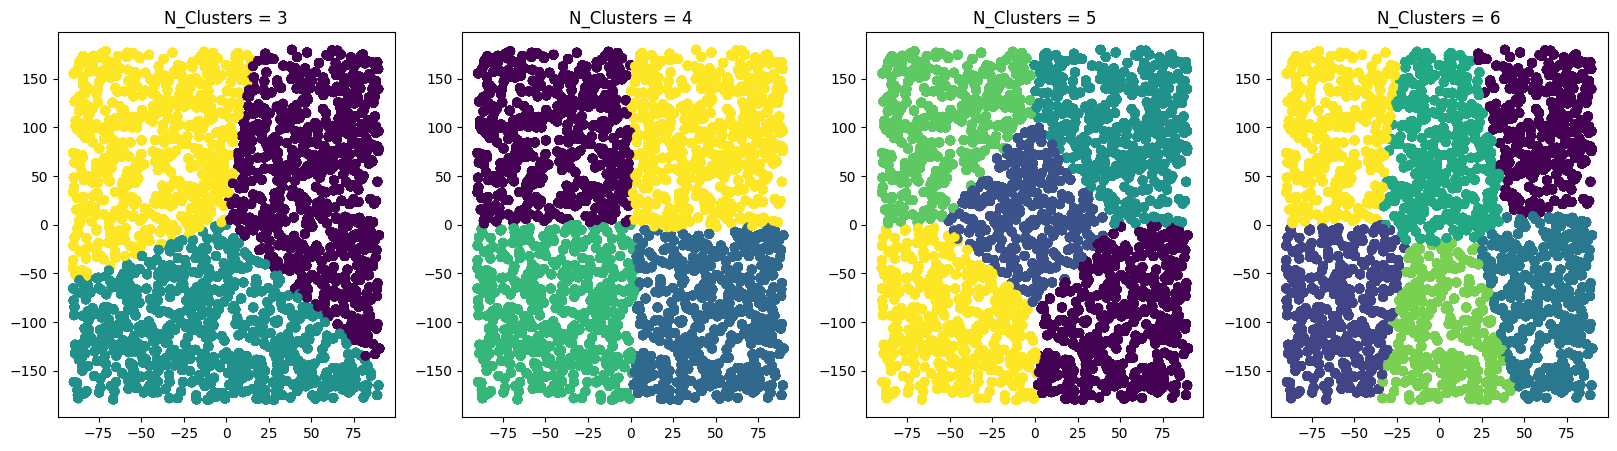

In [15]:
fig, axis = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

for i, ax in enumerate(fig.axes, start=3):
    ax.scatter(
        x=df["Customer Location Latitude"], 
        y=df["Customer Location Longitude"],
        c=df[f"K-Means = {i}"]
        )
    ax.set_title(f"N_Clusters = {i}")